# Comparer les modèles de prix Day-Ahead DE-LU

Ce notebook compare des configurations simples à la baseline D-7. Les modèles apprennent sur l'historique jusqu'à fin mai. En juin, juillet et août, la météo et la charge sont remplacées par les snapshots J-1 disponibles avant le cutoff. Juin sert à calibrer P10–P90 ; juillet et août restent le test final.

In [1]:
from pathlib import Path
import sys
import time

from sklearn.base import clone

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.features.day_ahead_price import (
    de_lu_model_feature_groups,
    de_lu_operational_feature_columns,
)
from src.modeling.common import build_candidate_models
from src.modeling.day_ahead_price import (
    apply_price_interval_adjustment,
    build_price_quantile_models,
    compare_predictions,
    conformal_price_interval_adjustment,
    fit_price_model,
    fit_price_quantile_models,
    price_forecast_metrics,
    predict_ordered_price_quantiles,
    price_probabilistic_metrics,
)

MARKET_TIMEZONE = 'Europe/Berlin'
CALIBRATION_START = pd.Timestamp('2026-06-01', tz=MARKET_TIMEZONE)
TEST_START = pd.Timestamp('2026-07-01', tz=MARKET_TIMEZONE)

## Préparer les variables utilisées au moment de la décision

L'entraînement utilise les données historiques déjà préparées. À partir de juin, les valeurs météo régionales et la charge sont remplacées par les prévisions J-1 collectées avant le cutoff. Les publications JAO et les retards de prix restent dans la table existante.

In [2]:
model_data = pd.read_parquet(
    PROJECT_ROOT / 'data' / 'modeling' / 'de_lu_day_ahead_price_training_full.parquet'
)
model_data['delivery_start_utc'] = pd.to_datetime(
    model_data['delivery_start_utc'], utc=True
)

# Les snapshots J-1 remplacent la météo et la charge à partir de juin.
j1_weather = pd.read_parquet(
    PROJECT_ROOT / 'data' / 'market_15m' / 'de_lu_regional_j1_forecast_weather_15m.parquet'
)
j1_load = pd.read_parquet(
    PROJECT_ROOT / 'data' / 'market_15m' / 'de_lu_system_j1_load_forecast_15m.parquet'
)
for frame in (j1_weather, j1_load):
    frame['delivery_start_utc'] = pd.to_datetime(frame['delivery_start_utc'], utc=True)

weather_columns = [
    column for column in j1_weather.columns
    if column != 'delivery_start_utc' and column in model_data.columns
]
j1_snapshot = j1_weather[['delivery_start_utc', *weather_columns]].merge(
    j1_load[['delivery_start_utc', 'national_load_mw']],
    on='delivery_start_utc', how='outer', suffixes=('', '_load'),
)
j1_columns = [column for column in j1_snapshot.columns if column != 'delivery_start_utc']
model_data = model_data.merge(
    j1_snapshot, on='delivery_start_utc', how='left', suffixes=('', '_j1')
)

local_time = model_data['delivery_start_utc'].dt.tz_convert(MARKET_TIMEZONE)
operational_period = local_time >= CALIBRATION_START
for column in j1_columns:
    model_data.loc[operational_period, column] = model_data.loc[
        operational_period, f'{column}_j1'
    ]
model_data = model_data.drop(columns=[f'{column}_j1' for column in j1_columns])

feature_groups = de_lu_model_feature_groups(model_data)
selected_features = de_lu_operational_feature_columns(model_data)
complete_rows = model_data[selected_features].notna().all(axis=1)
model_data = model_data.loc[complete_rows].copy()

native_data = model_data.loc[model_data['is_native_15m_target']].copy()
legacy_data = model_data.loc[~model_data['is_native_15m_target']].copy()

print(f'{len(selected_features)} variables retenues.')
print(f'{len(native_data):,} lignes natives et {len(legacy_data):,} lignes horaires.')
print('Juin J-1 : 29 journées complètes ; le 12 juin est absent de l’archive météo.')

81 variables retenues.
32,064 lignes natives et 44,736 lignes horaires.
Juin J-1 : 29 journées complètes ; le 12 juin est absent de l’archive météo.


La table contient les variables déjà préparées. La suite du notebook ne recrée donc ni les retards de prix voisins ni les colonnes JAO.

## Construire les trois validations temporelles

Les validations couvrent janvier–février, mars–avril et mai. À chaque passage, l'entraînement utilise uniquement le passé. L'ancien historique horaire peut être ajouté avec un poids `0,25` : quatre lignes répétées correspondent ainsi à une heure d'information.

In [3]:
native_local_time = native_data['delivery_start_utc'].dt.tz_convert(MARKET_TIMEZONE)
validation_windows = pd.DataFrame([
    {'fold': 'janvier_fevrier', 'start': '2026-01-01', 'end': '2026-03-01'},
    {'fold': 'mars_avril', 'start': '2026-03-01', 'end': '2026-05-01'},
    {'fold': 'mai', 'start': '2026-05-01', 'end': '2026-06-01'},
])

fold_data = {}
fold_summary = []
for window in validation_windows.itertuples(index=False):
    start = pd.Timestamp(window.start, tz=MARKET_TIMEZONE)
    end = pd.Timestamp(window.end, tz=MARKET_TIMEZONE)
    native_train = native_data.loc[native_local_time < start].copy()
    validation = native_data.loc[(native_local_time >= start) & (native_local_time < end)].copy()
    native_train['sample_weight'] = 1.0
    legacy_train = legacy_data.copy()
    legacy_train['sample_weight'] = 0.25
    mixed_train = pd.concat([legacy_train, native_train], ignore_index=True)
    fold_data[window.fold] = {'natif': native_train, 'mixte': mixed_train, 'validation': validation}
    fold_summary.extend([
        {'passage': window.fold, 'usage': 'train natif', 'lignes': len(native_train)},
        {'passage': window.fold, 'usage': 'train mixte', 'lignes': len(mixed_train)},
        {'passage': window.fold, 'usage': 'validation', 'lignes': len(validation)},
    ])

pd.DataFrame(fold_summary)

,passage,usage,lignes
0,janvier_fevrier,train natif,8836
1,janvier_fevrier,train mixte,53572
2,janvier_fevrier,validation,5664
3,mars_avril,train natif,14500
4,mars_avril,train mixte,59236
5,mars_avril,validation,5852
6,mai,train natif,20352
7,mai,train mixte,65088
8,mai,validation,2976


Chaque passage conserve un ordre strict : l'entraînement est antérieur à la période évaluée. La version mixte ajoute le même historique horaire à chaque passage, puisqu'il précède entièrement les données natives.

## Comparer les réglages et la mixité

La grille reste limitée : trois pénalités Ridge, deux tailles d'arbres pour HistGradientBoosting et LightGBM, deux profondeurs pour XGBoost. Chaque réglage est évalué séquentiellement sur les trois mêmes passages ; il n'y a pas de recherche automatique opaque.

In [4]:
candidate_models = build_candidate_models(random_state=42)
cv_records = []

for fold_name, frames in fold_data.items():
    validation = frames['validation']
    baseline_metrics = price_forecast_metrics(
        validation['day_ahead_price'], validation['price_lag_7d']
    )
    cv_records.append({'fold': fold_name, 'régime': 'baseline', 'famille': 'Baseline D-7', 'réglage': '-', **baseline_metrics})

    for regime_name in ('natif', 'mixte'):
        training_frame = frames[regime_name]
        for family_name, configurations in candidate_models.items():
            for configuration_name, template in configurations.items():
                model = clone(template)
                started_at = time.perf_counter()
                fit_price_model(
                    model, training_frame[selected_features],
                    training_frame['day_ahead_price'], training_frame['sample_weight'],
                )
                prediction = model.predict(validation[selected_features])
                metrics = price_forecast_metrics(validation['day_ahead_price'], prediction)
                cv_records.append({
                    'fold': fold_name, 'régime': regime_name,
                    'famille': family_name, 'réglage': configuration_name,
                    'entraînement (s)': time.perf_counter() - started_at, **metrics,
                })

cv_results = pd.DataFrame(cv_records)
cv_results.head()

,fold,régime,famille,réglage,MAE,RMSE,biais,entraînement (s)
0,janvier_fevrier,baseline,Baseline D-7,-,24.783256,38.943586,1.616730,NaN
1,janvier_fevrier,natif,Ridge,alpha_1,15.649591,20.606483,3.005048,0.427519
2,janvier_fevrier,natif,Ridge,alpha_10,15.745147,20.684224,3.394412,0.256384
3,janvier_fevrier,natif,Ridge,alpha_100,15.851052,20.769135,0.678403,0.166477
4,janvier_fevrier,natif,HistGradientBoosting,leaves_15,15.425597,21.898999,-4.076311,12.413040


Le tableau contient une ligne par réglage, régime et fold. Il donne les erreurs brutes avant leur synthèse : ce sont ces résultats hors échantillon qui servent au choix.

## Choisir une configuration stable

Je classe les candidats avec la MAE moyenne des trois fenêtres. L'écart-type et la pire MAE servent à vérifier qu'un gain moyen ne masque pas une période difficile. RMSE et biais restent des métriques de lecture.

In [5]:
candidate_results = cv_results.loc[cv_results['régime'] != 'baseline'].copy()
cv_summary = (
    candidate_results.groupby(['régime', 'famille', 'réglage'], as_index=False)
    .agg(MAE_moyenne=('MAE', 'mean'), MAE_ecart_type=('MAE', 'std'),
         pire_MAE=('MAE', 'max'), RMSE_moyen=('RMSE', 'mean'), biais_moyen=('biais', 'mean'))
    .sort_values(['MAE_moyenne', 'MAE_ecart_type', 'pire_MAE'])
    .reset_index(drop=True)
)
best_choice = cv_summary.iloc[0]
best_regime = best_choice['régime']
best_family = best_choice['famille']
best_configuration = best_choice['réglage']
selected_template = candidate_models[best_family][best_configuration]

display(cv_summary.round(2))
print(f"Choix : {best_family} {best_configuration} | {best_regime}")

mae_by_fold = candidate_results.pivot_table(
    index=['régime', 'famille', 'réglage'], columns='fold', values='MAE'
)[validation_windows['fold'].tolist()]
mae_by_fold.head(10).round(2)

,régime,famille,réglage,MAE_moyenne,MAE_ecart_type,pire_MAE,RMSE_moyen,biais_moyen
0,mixte,XGBoost,depth_6,18.09,3.47,21.06,27.78,-6.93
1,mixte,XGBoost,depth_4,18.48,3.83,21.11,28.64,-7.86
2,mixte,LightGBM,leaves_31,18.60,3.55,20.75,28.23,-8.04
3,mixte,LightGBM,leaves_63,18.64,3.14,20.58,28.41,-7.62
4,mixte,HistGradientBoosting,leaves_31,19.00,3.45,21.10,28.68,-8.24
5,mixte,HistGradientBoosting,leaves_15,19.13,4.18,21.56,29.06,-9.10
6,mixte,Ridge,alpha_100,19.34,5.05,24.10,28.96,-7.90
7,mixte,Ridge,alpha_10,19.69,5.35,24.40,29.18,-8.95
8,mixte,Ridge,alpha_1,19.74,5.39,24.44,29.23,-9.11
9,natif,XGBoost,depth_6,20.40,4.05,23.77,31.57,-6.68


Choix : XGBoost depth_6 | mixte


fold                                   janvier_fevrier  mars_avril    mai
régime famille              réglage                                      
mixte  HistGradientBoosting leaves_15            14.31       21.53  21.56
                            leaves_31            15.01       21.10  20.89
       LightGBM             leaves_31            14.51       20.75  20.56
                            leaves_63            15.02       20.58  20.33
       Ridge                alpha_1              13.86       20.94  24.44
                            alpha_10             13.87       20.79  24.40
                            alpha_100            14.04       19.87  24.10
       XGBoost              depth_4              14.09       21.11  20.26
                            depth_6              14.28       21.06  18.92
natif  HistGradientBoosting leaves_15            15.43       23.79  24.22

La configuration affichée en tête est celle retenue. Le tableau par fenêtre permet de vérifier si elle gagne régulièrement, ou seulement grâce à une période particulièrement favorable.

C:\Users\djamo\AppData\Local\Temp\ipykernel_2832\1018956533.py:38: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  error_by_block = block_errors.pivot_table(


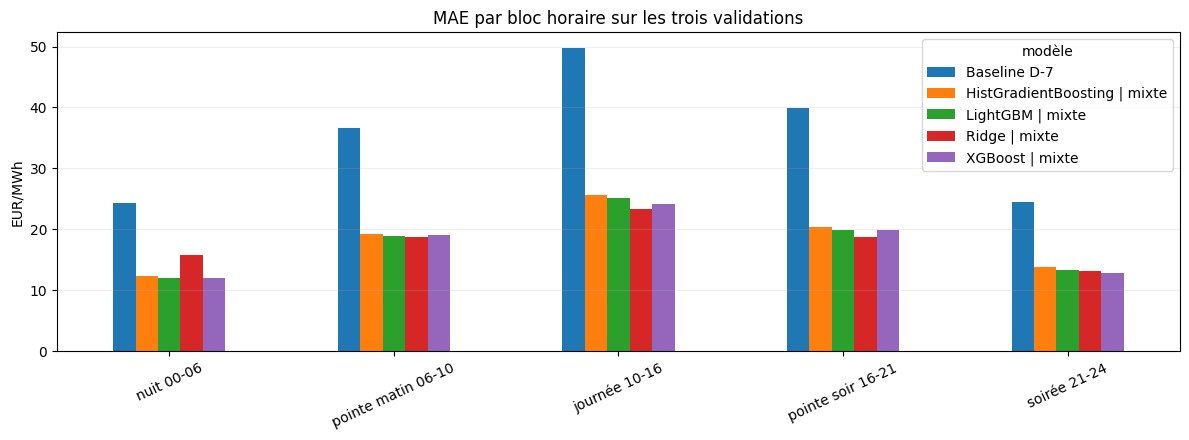

modèle,Baseline D-7,HistGradientBoosting | mixte,LightGBM | mixte,Ridge | mixte,XGBoost | mixte
bloc horaire,,,,,
nuit 00-06,24.35,12.32,12.08,15.74,12.02
pointe matin 06-10,36.62,19.24,18.95,18.73,19.01
journée 10-16,49.83,25.65,25.09,23.33,24.23
pointe soir 16-21,39.99,20.40,19.91,18.83,19.84
soirée 21-24,24.47,13.80,13.33,13.22,12.84


In [6]:
best_by_family = (
    cv_summary.sort_values(['famille', 'MAE_moyenne'])
    .groupby('famille', as_index=False)
    .first()
)
hour_block_labels = [
    'nuit 00-06', 'pointe matin 06-10', 'journée 10-16',
    'pointe soir 16-21', 'soirée 21-24',
]
block_error_rows = []

for fold_name, frames in fold_data.items():
    validation = frames['validation']
    hour_block = pd.cut(
        validation['delivery_start_utc'].dt.tz_convert(MARKET_TIMEZONE).dt.hour,
        bins=[0, 6, 10, 16, 21, 24], right=False, labels=hour_block_labels,
    )
    block_error_rows.append(pd.DataFrame({
        'modèle': 'Baseline D-7', 'bloc horaire': hour_block,
        'erreur absolue': np.abs(validation['price_lag_7d'] - validation['day_ahead_price']),
    }))

    for _, choice in best_by_family.iterrows():
        model = clone(candidate_models[choice['famille']][choice['réglage']])
        training = frames[choice['régime']]
        fit_price_model(
            model, training[selected_features], training['day_ahead_price'],
            training['sample_weight'],
        )
        prediction = model.predict(validation[selected_features])
        block_error_rows.append(pd.DataFrame({
            'modèle': f"{choice['famille']} | {choice['régime']}",
            'bloc horaire': hour_block,
            'erreur absolue': np.abs(prediction - validation['day_ahead_price'].to_numpy()),
        }))

block_errors = pd.concat(block_error_rows, ignore_index=True)
error_by_block = block_errors.pivot_table(
    index='bloc horaire', columns='modèle', values='erreur absolue', aggfunc='mean'
).reindex(hour_block_labels)

ax = error_by_block.plot.bar(figsize=(12, 4.5))
ax.set(title='MAE par bloc horaire sur les trois validations', xlabel='', ylabel='EUR/MWh')
ax.tick_params(axis='x', rotation=25)
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()
error_by_block.round(2)

## Ce que montre la validation

Les modèles mixtes améliorent la MAE dans tous les blocs horaires par rapport à la baseline D-7. XGBoost mixte est le meilleur ou quasiment le meilleur selon le bloc : sa MAE est de **12,02 EUR/MWh** la nuit, **19,01** le matin, **24,23** en journée, **19,84** à la pointe du soir et **12,84** en soirée. La période 10–16 est la plus difficile pour tous les modèles, tandis que les erreurs sont plus faibles la nuit et en soirée.

Cette comparaison décrit la robustesse du modèle selon l'heure locale ; elle ne remplace pas le classement global par MAE moyenne et ne modifie pas la configuration sélectionnée.

## Test final avec les informations J-1

Le choix est maintenant figé. Les modèles ponctuel et quantiles apprennent jusqu'à fin mai. Juin sert exclusivement à calibrer P10–P90 avec les snapshots météo et charge J-1. Juillet et août utilisent les mêmes types de données et restent le test final.

In [7]:
native_before_calibration = native_data.loc[native_local_time < CALIBRATION_START].copy()
calibration = native_data.loc[
    (native_local_time >= CALIBRATION_START) & (native_local_time < TEST_START)
].copy()
test = native_data.loc[native_local_time >= TEST_START].copy()
native_before_calibration['sample_weight'] = 1.0
legacy_before_calibration = legacy_data.copy()
legacy_before_calibration['sample_weight'] = 0.25

if best_regime == 'mixte':
    final_training = pd.concat(
        [legacy_before_calibration, native_before_calibration], ignore_index=True
    ).sort_values('delivery_start_utc')
else:
    final_training = native_before_calibration

final_model = clone(selected_template)
fit_price_model(
    final_model, final_training[selected_features],
    final_training['day_ahead_price'], final_training['sample_weight'],
)
selected_model_name = f'{best_family} | {best_regime}'
test_predictions = {
    'Baseline D-7': test['price_lag_7d'].to_numpy(),
    selected_model_name: final_model.predict(test[selected_features]),
}
test_results = compare_predictions(test['day_ahead_price'], test_predictions)
print(f"Entraînement final : {len(final_training):,} lignes pour la période allant jusqu'à fin mai.")
print(f"Calibration : {len(calibration):,} quarts d'heure en juin.")
print(f"Test : {len(test):,} quarts d'heure, du {test['delivery_start_utc'].min().tz_convert(MARKET_TIMEZONE):%d/%m/%Y} au {test['delivery_start_utc'].max().tz_convert(MARKET_TIMEZONE):%d/%m/%Y}.")
test_results.round(2)

Entraînement final : 68,064 lignes pour la période allant jusqu'à fin mai.
Calibration : 2,784 quarts d'heure en juin.
Test : 5,952 quarts d'heure, du 01/07/2026 au 31/08/2026.


,modèle,MAE,RMSE,biais
0,XGBoost | mixte,21.04,27.34,-10.17
1,Baseline D-7,34.26,53.32,2.43


Le tableau compare le modèle figé à D-7 sur tout le test. Le modèle n'est plus modifié après cette étape.

## Où le modèle se trompe-t-il ?

On regarde les erreurs par mois et par bloc horaire. Cela ne sert plus à modifier le modèle : c'est une lecture du risque résiduel pour un trader.

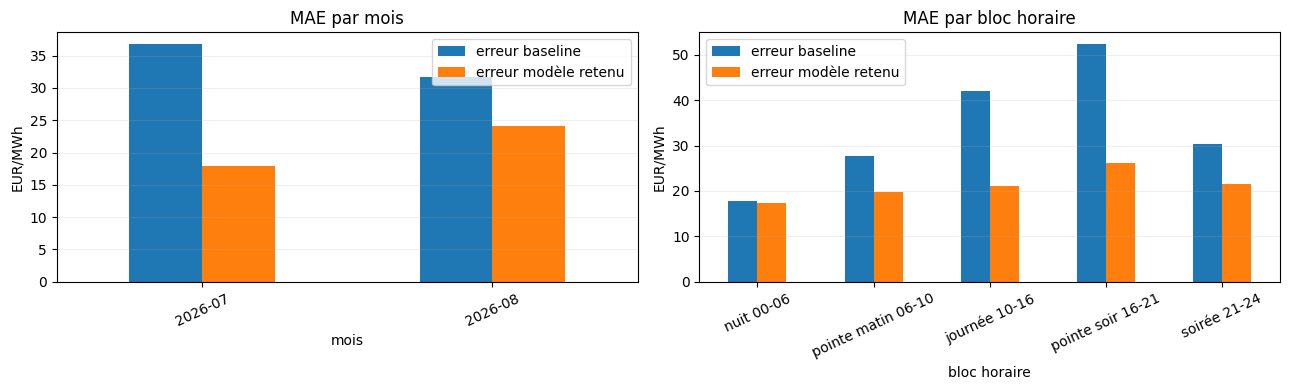

,erreur baseline,erreur modèle retenu
mois,,
2026-07,36.77,17.98
2026-08,31.76,24.11


,erreur baseline,erreur modèle retenu
bloc horaire,,
nuit 00-06,17.84,17.38
pointe matin 06-10,27.81,19.73
journée 10-16,41.92,21.05
pointe soir 16-21,52.33,26.14
soirée 21-24,30.30,21.61


In [8]:
test_local_time = test['delivery_start_utc'].dt.tz_convert(MARKET_TIMEZONE)
test_errors = pd.DataFrame({
    'mois': test_local_time.dt.strftime('%Y-%m'),
    'bloc horaire': pd.cut(
        test_local_time.dt.hour, bins=[0, 6, 10, 16, 21, 24], right=False,
        labels=['nuit 00-06', 'pointe matin 06-10', 'journée 10-16', 'pointe soir 16-21', 'soirée 21-24'],
    ),
    'erreur baseline': np.abs(test_predictions['Baseline D-7'] - test['day_ahead_price'].to_numpy()),
    'erreur modèle retenu': np.abs(test_predictions[selected_model_name] - test['day_ahead_price'].to_numpy()),
})

mae_by_month = test_errors.groupby('mois')[['erreur baseline', 'erreur modèle retenu']].mean()
mae_by_block = test_errors.groupby('bloc horaire', observed=True)[['erreur baseline', 'erreur modèle retenu']].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
mae_by_month.plot.bar(ax=axes[0], title='MAE par mois', ylabel='EUR/MWh')
mae_by_block.plot.bar(ax=axes[1], title='MAE par bloc horaire', ylabel='EUR/MWh')
for axis in axes:
    axis.grid(axis='y', alpha=0.2)
    axis.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()

display(mae_by_month.round(2))
mae_by_block.round(2)

La comparaison mensuelle et par bloc indique si le gain global se retrouve à différents moments de la journée. Elle ne sert pas à refaire le tuning.

## Journées de prix extrême et éclipse du 12 août 2026

Les journées extrêmes sont définies ici à partir des prix réalisés du test : les deux plus hauts maxima et les deux plus bas minima journaliers. C'est une analyse a posteriori, utile pour comprendre le risque mais évidemment indisponible lors d'une prévision. On ajoute le 12 août 2026 séparément, date de l'éclipse solaire partielle en Allemagne.

,min,max,erreur_baseline,erreur_modele
2026-07-25 00:00:00+02:00,-15.01,176.87,16.31,20.27
2026-08-08 00:00:00+02:00,-18.49,191.72,21.42,16.24
2026-08-12 00:00:00+02:00,0.00,461.17,29.47,23.10
2026-08-13 00:00:00+02:00,-0.01,487.38,49.44,32.30


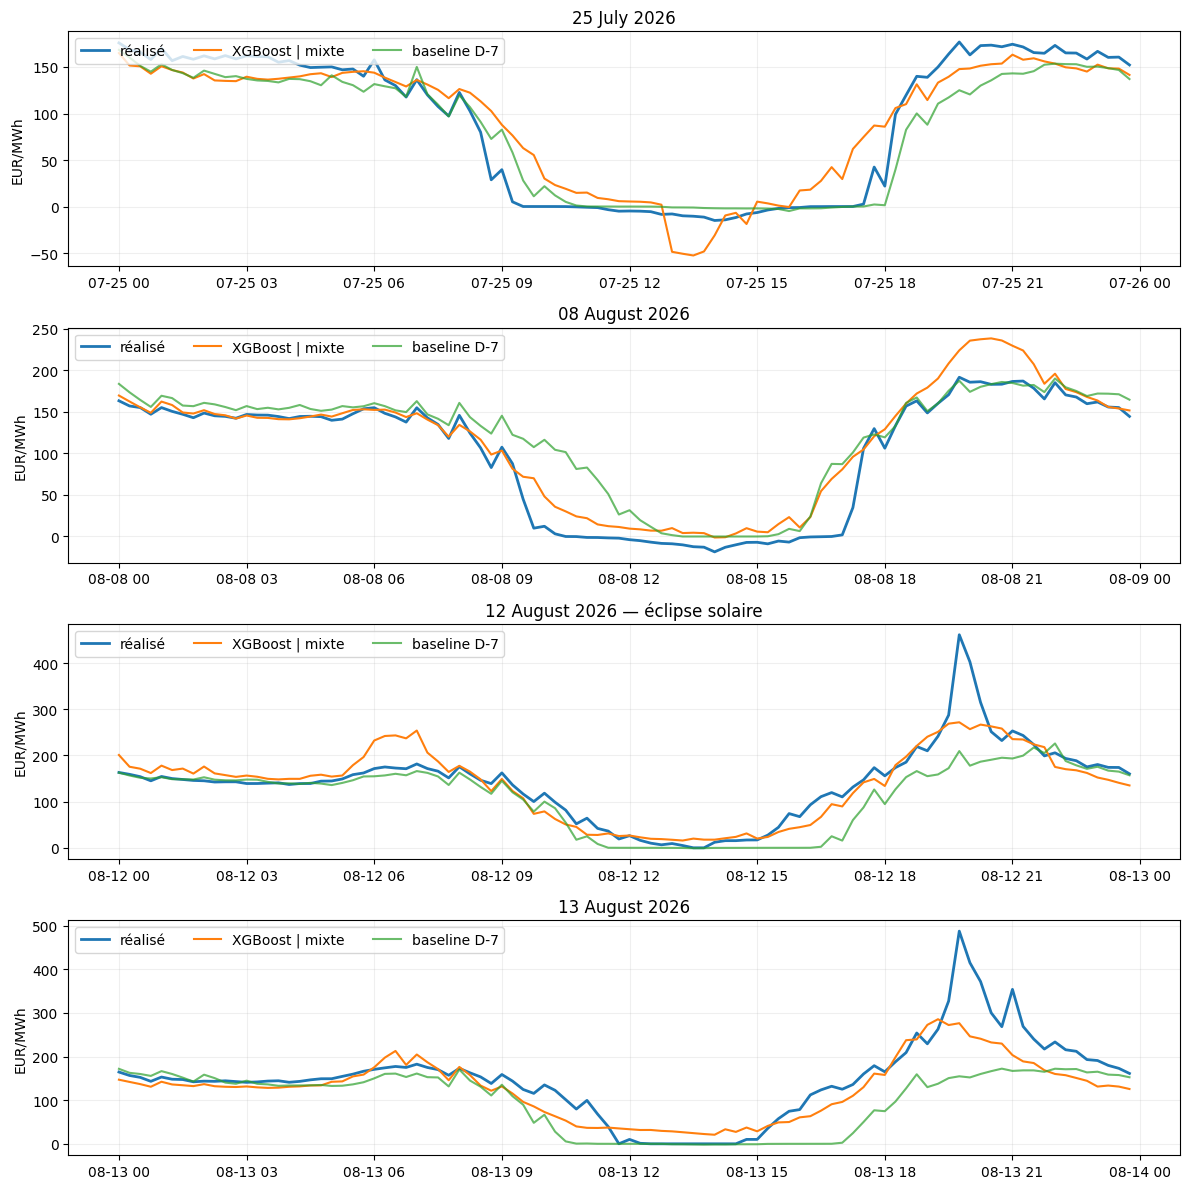

In [9]:
test_plot = pd.DataFrame({
    'delivery_start_local': test_local_time,
    'prix réalisé': test['day_ahead_price'].to_numpy(),
    'baseline D-7': test_predictions['Baseline D-7'],
    selected_model_name: test_predictions[selected_model_name],
})
test_plot['jour'] = test_plot['delivery_start_local'].dt.normalize()
daily_prices = test_plot.groupby('jour')['prix réalisé'].agg(['min', 'max'])
daily_errors = test_plot.assign(
    erreur_baseline=np.abs(test_plot['baseline D-7'] - test_plot['prix réalisé']),
    erreur_modele=np.abs(test_plot[selected_model_name] - test_plot['prix réalisé']),
).groupby('jour')[['erreur_baseline', 'erreur_modele']].mean()
extreme_days = daily_prices.nlargest(2, 'max').index.union(daily_prices.nsmallest(2, 'min').index)
eclipse_day = pd.Timestamp('2026-08-12', tz=MARKET_TIMEZONE)
days_to_review = extreme_days.union(pd.DatetimeIndex([eclipse_day])).sort_values()

daily_review = daily_prices.join(daily_errors).loc[days_to_review]
display(daily_review.round(2))

fig, axes = plt.subplots(len(days_to_review), 1, figsize=(12, 3 * len(days_to_review)), sharex=False)
for axis, day in zip(np.atleast_1d(axes), days_to_review):
    one_day = test_plot.loc[test_plot['jour'] == day]
    axis.plot(one_day['delivery_start_local'], one_day['prix réalisé'], label='réalisé', linewidth=2)
    axis.plot(one_day['delivery_start_local'], one_day[selected_model_name], label=selected_model_name)
    axis.plot(one_day['delivery_start_local'], one_day['baseline D-7'], label='baseline D-7', alpha=0.7)
    label = ' — éclipse solaire' if day == eclipse_day else ''
    axis.set(title=f"{day:%d %B %Y}{label}", ylabel='EUR/MWh')
    axis.grid(alpha=0.2)
    axis.legend(ncol=3, loc='upper left')
plt.tight_layout()
plt.show()

Les journées affichées servent à voir la forme des erreurs lors de cas difficiles. Elles sont choisies après le test et ne participent donc pas au choix du modèle.

## Donner une fourchette de prix : P10, P50 et P90

Les trois modèles quantiles reprennent les réglages du modèle à arbres retenu par validation temporelle. Ils apprennent jusqu'à fin mai. Juin sert uniquement à calibrer la largeur de l'intervalle central P10–P90 pour viser 80 % de couverture.

In [10]:
quantile_models = fit_price_quantile_models(
    build_price_quantile_models(selected_template),
    final_training[selected_features],
    final_training['day_ahead_price'],
    final_training['sample_weight'],
)

calibration_quantiles_raw, calibration_crossing_rate = predict_ordered_price_quantiles(
    quantile_models, calibration[selected_features]
)
interval_adjustment = conformal_price_interval_adjustment(
    calibration['day_ahead_price'], calibration_quantiles_raw
)
calibration_quantiles = apply_price_interval_adjustment(
    calibration_quantiles_raw, interval_adjustment
)
test_quantiles_raw, test_crossing_rate = predict_ordered_price_quantiles(
    quantile_models, test[selected_features]
)
test_quantiles = apply_price_interval_adjustment(
    test_quantiles_raw, interval_adjustment
)

probabilistic_results = pd.DataFrame([
    {'période': 'juin calibré', **price_probabilistic_metrics(calibration['day_ahead_price'], calibration_quantiles)},
    {'période': 'test', **price_probabilistic_metrics(test['day_ahead_price'], test_quantiles)},
])
print(f'Ajustement conformal : {interval_adjustment:.2f} EUR/MWh de chaque côté.')
print(f'Croisements bruts P10/P50/P90 : juin {calibration_crossing_rate:.2%}, test {test_crossing_rate:.2%}.')
probabilistic_results.round(2)

Ajustement conformal : 5.22 EUR/MWh de chaque côté.
Croisements bruts P10/P50/P90 : juin 3.45%, test 4.69%.


,période,p10_pinball_loss,p50_pinball_loss,p90_pinball_loss,p10_p90_coverage_pct,mean_interval_width_eur_mwh
0,juin calibré,4.38,10.31,7.64,80.03,54.48
1,test,4.56,11.63,5.41,66.05,56.54


Juin règle l'élargissement de l'intervalle à partir des snapshots J-1. Le tableau indique ensuite si la couverture se conserve sur juillet–août, avec les mêmes informations disponibles avant le Day-Ahead.

### Lire une journée risquée

La bande bleue est la zone P10–P90 : elle ne signifie pas que le prix restera à l'intérieur à chaque quart d'heure, mais qu'elle vise environ 80 % de couverture sur une longue série. On reprend l'éclipse du 12 août, déjà étudiée dans le test.

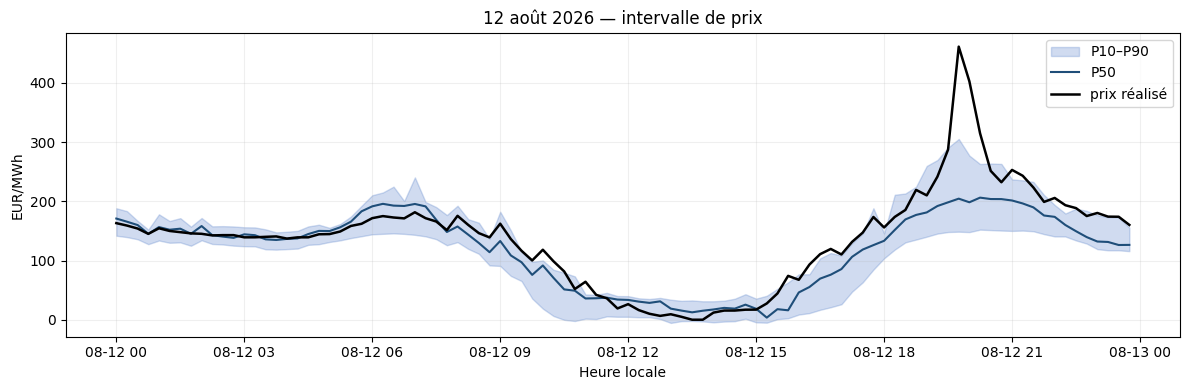

In [11]:
eclipse_filter = test_local_time.dt.normalize() == eclipse_day
eclipse_time = test_local_time.loc[eclipse_filter]
eclipse_actual = test.loc[eclipse_filter, 'day_ahead_price']
eclipse_quantiles = test_quantiles.loc[eclipse_filter]

fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(eclipse_time, eclipse_quantiles['p10_eur_mwh'], eclipse_quantiles['p90_eur_mwh'], color='#4472C4', alpha=0.25, label='P10–P90')
ax.plot(eclipse_time, eclipse_quantiles['p50_eur_mwh'], color='#1F4E79', label='P50')
ax.plot(eclipse_time, eclipse_actual, color='black', linewidth=1.8, label='prix réalisé')
ax.set(title='12 août 2026 — intervalle de prix', xlabel='Heure locale', ylabel='EUR/MWh')
ax.grid(alpha=0.2)
ax.legend()
plt.tight_layout()
plt.show()

Cette journée montre la bande autour du scénario central. Une sortie de bande reste possible : une couverture à 80 % laisse volontairement des observations en dehors.

## Expliquer la prévision P50 retenue

Les contributions TreeSHAP expliquent le modèle P50 retenu. Une contribution positive pousse la prévision au-dessus de sa valeur de référence ; une contribution négative la réduit. Elles expliquent le comportement du modèle, pas une relation causale entre une variable et le prix.

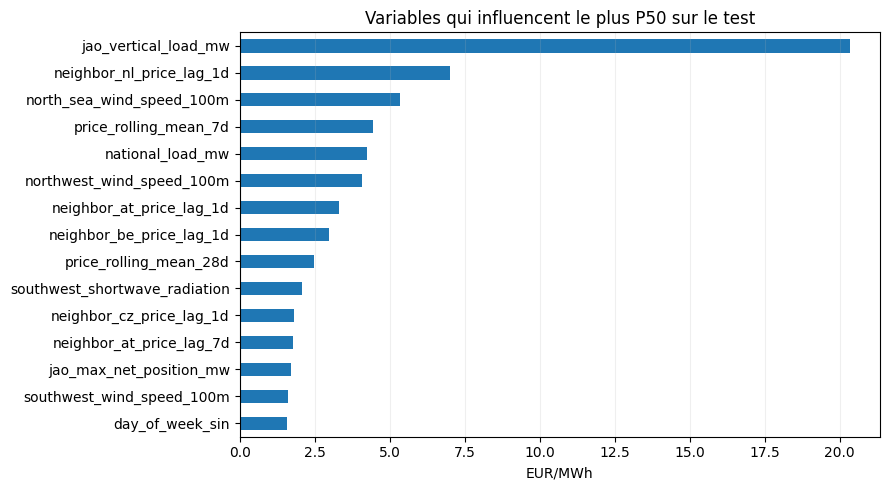

,contribution absolue moyenne (EUR/MWh)
famille,
jao_pre_clearing,29.770000
meteo_regionale,23.580000
prix_voisins_retardes,23.290001
historique_prix_de_lu,10.060000
calendrier,5.180000
charge,4.250000


,contribution absolue moyenne (EUR/MWh)
jao_vertical_load_mw,20.32
neighbor_nl_price_lag_1d,7.02
north_sea_wind_speed_100m,5.35
price_rolling_mean_7d,4.44
national_load_mw,4.25
northwest_wind_speed_100m,4.09
neighbor_at_price_lag_1d,3.33
neighbor_be_price_lag_1d,2.96
price_rolling_mean_28d,2.49
southwest_shortwave_radiation,2.07


In [12]:
p50_model = quantile_models['p50_eur_mwh']
# XGBoost et LightGBM calculent leurs contributions TreeSHAP directement.
if hasattr(p50_model, 'get_booster'):
    test_matrix = xgb.DMatrix(test[selected_features], feature_names=selected_features)
    shap_values = p50_model.get_booster().predict(test_matrix, pred_contribs=True)
elif hasattr(p50_model, 'booster_'):
    shap_values = p50_model.predict(test[selected_features], pred_contrib=True)
else:
    raise ValueError('TreeSHAP nécessite XGBoost ou LightGBM pour le modèle retenu.')
shap_contributions = pd.DataFrame(shap_values[:, :-1], columns=selected_features, index=test.index)
shap_baseline = shap_values[:, -1]

shap_feature_importance = (
    shap_contributions.abs().mean().sort_values(ascending=False).rename('contribution absolue moyenne (EUR/MWh)').to_frame()
)
feature_to_group = {column: group for group, columns in feature_groups.items() for column in columns}
shap_group_importance = (
    shap_feature_importance.assign(famille=lambda frame: frame.index.map(feature_to_group))
    .groupby('famille')['contribution absolue moyenne (EUR/MWh)'].sum()
    .sort_values(ascending=False).to_frame()
)

fig, ax = plt.subplots(figsize=(9, 5))
shap_feature_importance.head(15).sort_values('contribution absolue moyenne (EUR/MWh)').plot.barh(ax=ax, legend=False)
ax.set(title='Variables qui influencent le plus P50 sur le test', xlabel='EUR/MWh')
ax.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.show()

display(shap_group_importance.round(2))
shap_feature_importance.head(15).round(2)

Le premier graphique regroupe les effets par variable ; le second liste les variables individuelles qui portent le plus d'effet sur P50.

### Une prévision précise pendant l'éclipse

On explique le quart d'heure au prix réalisé le plus élevé du 12 août. La somme de la référence et de toutes les contributions reproduit la prévision P50 de XGBoost.

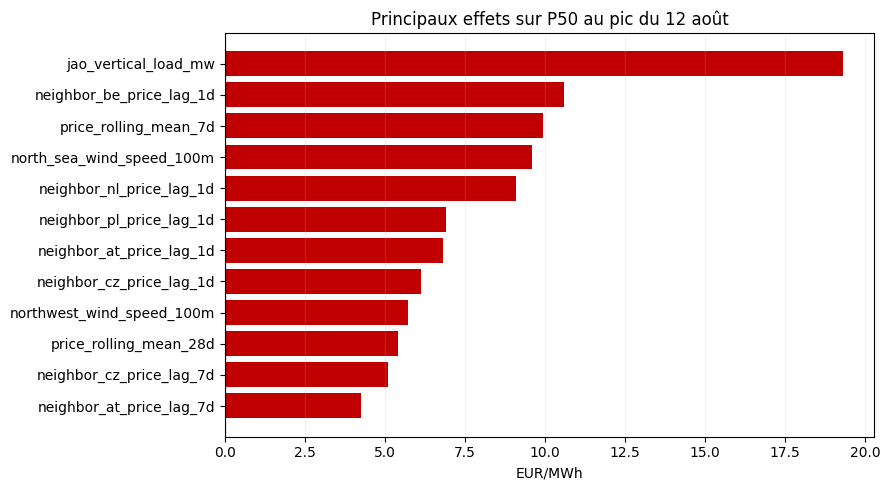

Quart d'heure expliqué : 12/08/2026 19:45.
Référence : 92.36 | somme SHAP + référence : 204.46 | P50 brut : 204.46.


,variable,valeur,contribution SHAP (EUR/MWh)
70,neighbor_at_price_lag_7d,307.49,4.240000
74,neighbor_cz_price_lag_7d,337.95,5.080000
11,price_rolling_mean_28d,198.043214,5.390000
19,northwest_wind_speed_100m,4.8,5.720000
73,neighbor_cz_price_lag_1d,241.01,6.130000
69,neighbor_at_price_lag_1d,254.23,6.820000
79,neighbor_pl_price_lag_1d,283.2,6.910000
77,neighbor_nl_price_lag_1d,206.47,9.090000
44,north_sea_wind_speed_100m,5.77,9.570000
10,price_rolling_mean_7d,190.342857,9.940000


In [13]:
eclipse_positions = np.flatnonzero(eclipse_filter.to_numpy())
eclipse_peak_position = eclipse_positions[np.argmax(eclipse_actual.to_numpy())]
local_contributions = pd.DataFrame({
    'variable': selected_features,
    'valeur': test.iloc[eclipse_peak_position][selected_features].to_numpy(),
    'contribution SHAP (EUR/MWh)': shap_contributions.iloc[eclipse_peak_position].to_numpy(),
})
local_contributions['contribution absolue'] = local_contributions['contribution SHAP (EUR/MWh)'].abs()
local_top = local_contributions.nlargest(12, 'contribution absolue').sort_values('contribution SHAP (EUR/MWh)')
local_prediction = shap_baseline[eclipse_peak_position] + shap_contributions.iloc[eclipse_peak_position].sum()

fig, ax = plt.subplots(figsize=(9, 5))
colors = np.where(local_top['contribution SHAP (EUR/MWh)'] >= 0, '#C00000', '#4472C4')
ax.barh(local_top['variable'], local_top['contribution SHAP (EUR/MWh)'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set(title='Principaux effets sur P50 au pic du 12 août', xlabel='EUR/MWh')
ax.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.show()

print(f"Quart d'heure expliqué : {test_local_time.iloc[eclipse_peak_position]:%d/%m/%Y %H:%M}.")
print(f"Référence : {shap_baseline[eclipse_peak_position]:.2f} | somme SHAP + référence : {local_prediction:.2f} | P50 brut : {p50_model.predict(test.iloc[[eclipse_peak_position]][selected_features])[0]:.2f}.")
local_top[['variable', 'valeur', 'contribution SHAP (EUR/MWh)']].round(2)

## Bilan du test

Les résultats ci-dessus résument l'évaluation finale : le modèle est entraîné jusqu'à fin mai, calibré en juin et testé sur juillet–août avec les snapshots J-1 disponibles au cutoff. La lecture par bloc horaire, par mois et sur les journées extrêmes complète la MAE globale avant d'utiliser les prévisions dans le backtest portefeuille.